In [2]:
# Week 1 - Foundation
# FinSight AI - Intelligent Financial Risk & Insights Platform
# Topics: Python basics, pandas, numpy, data visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("FinSight AI - Week 1 Started ✅")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")

FinSight AI - Week 1 Started ✅
pandas: 3.0.3
numpy: 2.4.4


DAY 2 - Loading and Exploring the Lending Club Dataset

In [3]:
dataset = pd.read_csv('data/loan.csv')
print("Dataset loaded successfully!")

C:\Users\DELL\AppData\Local\Temp\ipykernel_19228\614267597.py:1: DtypeWarning: Columns (0: desc, 1: next_pymnt_d, 2: verification_status_joint, 3: sec_app_earliest_cr_line, 4: hardship_type, 5: hardship_reason, 6: hardship_status, 7: hardship_start_date, 8: hardship_end_date, 9: payment_plan_start_date, 10: hardship_loan_status, 11: debt_settlement_flag_date, 12: settlement_status, 13: settlement_date) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset = pd.read_csv('data/loan.csv')


Dataset loaded successfully!


In [4]:
dataset.shape

(2260668, 145)

In [5]:
dataset.head(10)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000.0,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000.0,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,5550,5550,5550.0,36 months,15.02,192.45,C,C3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,2000,2000,2000.0,36 months,17.97,72.28,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,6000,6000,6000.0,36 months,13.56,203.79,C,C1,...,NaN,NaN,DirectPay,N,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,6000,6000,6000.0,36 months,14.47,206.44,C,C2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
dataset.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='str', length=145)

In [7]:
dataset.isna()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,True,True,False,False,False,False,False,False,False,False,...,True,True,False,False,True,True,True,True,True,True
1,True,True,False,False,False,False,False,False,False,False,...,True,True,False,False,True,True,True,True,True,True
2,True,True,False,False,False,False,False,False,False,False,...,True,True,False,False,True,True,True,True,True,True
3,True,True,False,False,False,False,False,False,False,False,...,True,True,False,False,True,True,True,True,True,True
4,True,True,False,False,False,False,False,False,False,False,...,True,True,False,False,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260663,True,True,False,False,False,False,False,False,False,False,...,True,True,False,False,True,True,True,True,True,True
2260664,True,True,False,False,False,False,False,False,False,False,...,True,True,False,False,True,True,True,True,True,True
2260665,True,True,False,False,False,False,False,False,False,False,...,True,True,False,False,True,True,True,True,True,True
2260666,True,True,False,False,False,False,False,False,False,False,...,True,True,False,False,True,True,True,True,True,True


In [8]:
dataset.isna().sum()

id                       2260668
member_id                2260668
loan_amnt                      0
funded_amnt                    0
funded_amnt_inv                0
                          ...   
settlement_status        2227612
settlement_date          2227612
settlement_amount        2227612
settlement_percentage    2227612
settlement_term          2227612
Length: 145, dtype: int64

We can see that first and last column are entirely empty. They kind of look important.

In [9]:
dataset.isna().sum().sum()

np.int64(108666958)

What percentage of loans are defaulted?

In [10]:
dataset['loan_status'].value_counts()

loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64

Text(0.5, 1.0, 'Loan Count by Grade')

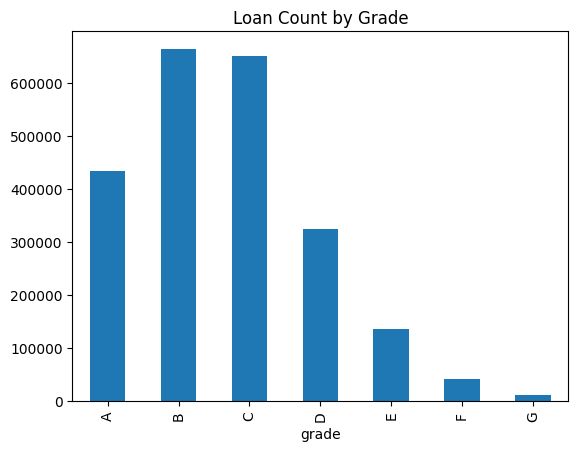

In [15]:
dataset.groupby('grade').size().plot(kind='bar')
plt.title('Loan Count by Grade')

In [20]:
dataset['loan_status'].unique()

<StringArray>
[                                            'Current',
                                          'Fully Paid',
                                  'Late (31-120 days)',
                                     'In Grace Period',
                                         'Charged Off',
                                   'Late (16-30 days)',
                                             'Default',
  'Does not meet the credit policy. Status:Fully Paid',
 'Does not meet the credit policy. Status:Charged Off']
Length: 9, dtype: str

These loan statuses should be considered defaulted:

Charged Off
Default
Late (31-120 days)
Does not meet the credit policy. Status:Charged Off

In [28]:
dataset[(dataset['loan_status'] == 'Charged Off') | (dataset['loan_status'] == 'Default') | (dataset['loan_status'] == 'Late (16-30 days)') | (dataset['loan_status'] == 'Does not meet the credit policy. Status:Charged Off')]

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
5040,NaN,NaN,8000,8000,8000.0,36 months,6.46,245.05,A,A1,...,NaN,NaN,DirectPay,N,NaN,NaN,NaN,NaN,NaN,NaN
9620,NaN,NaN,16000,16000,16000.0,36 months,15.02,554.81,C,C3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
18860,NaN,NaN,10000,10000,10000.0,36 months,15.02,346.76,C,C3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
22225,NaN,NaN,12000,12000,12000.0,36 months,16.91,427.30,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
22452,NaN,NaN,30000,30000,30000.0,36 months,18.94,1098.78,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260633,NaN,NaN,30000,30000,29725.0,60 months,30.17,973.74,F,F3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260638,NaN,NaN,30000,30000,30000.0,36 months,21.45,1137.20,D,D5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260640,NaN,NaN,20700,20700,20700.0,60 months,12.62,466.98,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260654,NaN,NaN,30000,30000,30000.0,60 months,17.09,747.03,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
dataset['is_default'] = dataset['loan_status'].isin(['Charged Off','Late (16-30 days)','Default','Does not meet the credit policy. Status:Charged Off'])


C:\Users\DELL\AppData\Local\Temp\ipykernel_19228\1465276418.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dataset['is_default'] = dataset['loan_status'].isin(['Charged Off',


0          False
1          False
2          False
3          False
4          False
           ...  
2260663    False
2260664    False
2260665    False
2260666    False
2260667    False
Name: is_default, Length: 2260668, dtype: bool

In [30]:
dataset['is_default'] = dataset['is_default'].astype(int)

In [39]:
dataset['is_default'].unique()

array([0, 1])

In [32]:
dataset['is_default'].head()

0    0
1    0
2    0
3    0
4    0
Name: is_default, dtype: int64

In [40]:
dataset['is_default'].mean() * 100

np.float64(11.774572825377277)

In [44]:
dataset.groupby('grade')['is_default'].mean() * 100

grade
A     3.242985
B     7.835348
C    13.036783
D    18.640729
E    26.438561
F    34.622010
G    37.762985
Name: is_default, dtype: float64

Loan grade is a strong predictor of default — Grade G borrowers default at 11x the rate of Grade A borrowers, validating the grading system as a core risk signal.

In [61]:
dataset.drop(['NAN %', 'Empty%'], axis=1, inplace= True)

Large chunk of this dataset is empty

In [66]:
(dataset.isna().sum() / dataset.shape[0] * 100).sort_values(ascending=False).head(30)

id                                            100.000000
member_id                                     100.000000
url                                           100.000000
orig_projected_additional_accrued_interest     99.627278
deferral_term                                  99.530537
hardship_start_date                            99.530537
hardship_loan_status                           99.530537
hardship_payoff_balance_amount                 99.530537
hardship_end_date                              99.530537
hardship_type                                  99.530537
hardship_last_payment_amount                   99.530537
hardship_amount                                99.530537
hardship_status                                99.530537
hardship_reason                                99.530537
hardship_dpd                                   99.530537
hardship_length                                99.530537
payment_plan_start_date                        99.530537
settlement_term                